This notebook is only to combine the explained variance ratio of TiO2/SiO2 and NMC-LGPS in one graph

In [2]:
import io
import os
import time
import json
import pickle
from pathlib import Path
from math import log, sqrt
from functools import partial
import string

import h5py
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

from sklearn.decomposition import NMF, PCA

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.patheffects as patheffects

In [3]:
with h5py.File('data/NMC_LGPS_dataset.h5', 'r') as f:
    # Load the datacube into memory
    X = np.array(f['X4D'])
    Xr = np.array(f['coordinates/x_real'])
    Yr = np.array(f['coordinates/y_real'])
    Xq = np.array(f['coordinates/x_reciprocal'])
    Yq = np.array(f['coordinates/y_reciprocal'])
    meta = json.loads(f['metadata'][()])
    beamstop = np.array(f['coordinates/beamstop'])

x_real, y_real, x_reci, y_reci = X.shape

Xf_BATT = X.reshape(X.shape[0] * X.shape[1], X.shape[2] * X.shape[3])
Xf_BATT = Xf_BATT.clip(min=0, max=1e32)

with h5py.File('data/TiO2_dataset.h5', 'r') as f:
    # Load the datacube into memory
    X = np.array(f['X4D'])
    Xr = np.array(f['coordinates/x_real'])
    Yr = np.array(f['coordinates/y_real'])
    Xq = np.array(f['coordinates/x_reciprocal'])
    Yq = np.array(f['coordinates/y_reciprocal'])
    meta = json.loads(f['metadata'][()])
    beamstop = np.array(f['coordinates/beamstop'])

x_real, y_real, x_reci, y_reci = X.shape

Xf_TiO2 = X.reshape(X.shape[0] * X.shape[1], X.shape[2] * X.shape[3])
Xf_TiO2 = Xf_TiO2.clip(min=0, max=1e32)

In [7]:

pca_TiO2 = PCA(n_components = 20)
W = pca_TiO2.fit_transform(Xf_TiO2)

pca_BATT = PCA(n_components = 50)
W = pca_BATT.fit_transform(Xf_BATT)

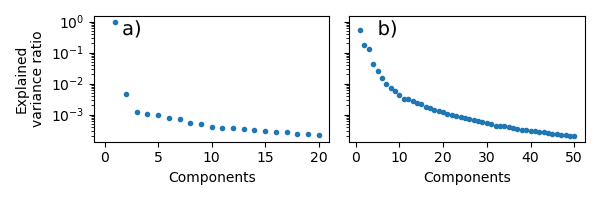

In [21]:
import string
import matplotlib.patheffects as patheffects

fig, axs = plt.subplots(ncols=2, nrows=1, sharey=True, figsize=(6,2))
axs[0].plot(np.arange(20) + 1, pca_TiO2.explained_variance_ratio_, '.')
axs[1].plot(np.arange(50) + 1, pca_BATT.explained_variance_ratio_, '.')
axs[0].set_ylabel('Explained\nvariance ratio')
axs[0].set_xlabel('Components')
axs[1].set_xlabel('Components')
axs[0].set_yscale('log')

axs[0].set_xlim([-1, 21])
axs[1].set_xticks([0,10,20,30,40,50])
# plt.ylim([1e-3, 1])
plt.tight_layout()
axs[0].text(0.12, 0.97, 'a)', transform=axs[0].transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])
axs[1].text(0.12, 0.97, 'b)', transform=axs[1].transAxes, fontsize=14, va='top', ha='left',
    color='k', path_effects=[patheffects.withStroke(linewidth=1, foreground='w')])
plt.savefig('figures/EVRs.png', dpi=300)